In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df_master = pd.read_csv("../data/processed/master_data.csv")
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])
print("Loaded:", df_master.shape)

Loaded: (118434, 23)


In [2]:
# Reference date = day after last order
reference_date = df_master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Keep only delivered orders
delivered = df_master[df_master['order_status'] == 'delivered'].copy()

rfm = delivered.groupby('customer_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('payment_value', 'sum')
).reset_index()

print("RFM Table Shape:", rfm.shape)
print(rfm.describe())

RFM Table Shape: (96478, 4)
            Recency  Frequency       Monetary
count  96478.000000    96478.0   96478.000000
mean     289.284573        1.0     204.981037
std      152.836939        0.0     621.236788
min       50.000000        1.0       0.000000
25%      165.000000        1.0      62.660000
50%      270.000000        1.0     109.500000
75%      399.000000        1.0     195.530000
max      763.000000        1.0  109312.640000


In [3]:
# Score each dimension 1-5
rfm['R_Score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = (rfm['R_Score'].astype(int) + 
                    rfm['F_Score'].astype(int) + 
                    rfm['M_Score'].astype(int))

# Assign segments
def segment(score):
    if score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal'
    elif score >= 7: return 'At Risk'
    elif score >= 4: return 'Needs Attention'
    else: return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)
print(rfm['Segment'].value_counts())

Segment
At Risk            39822
Loyal              33193
Needs Attention    14887
Champions           7781
Lost                 795
Name: count, dtype: int64


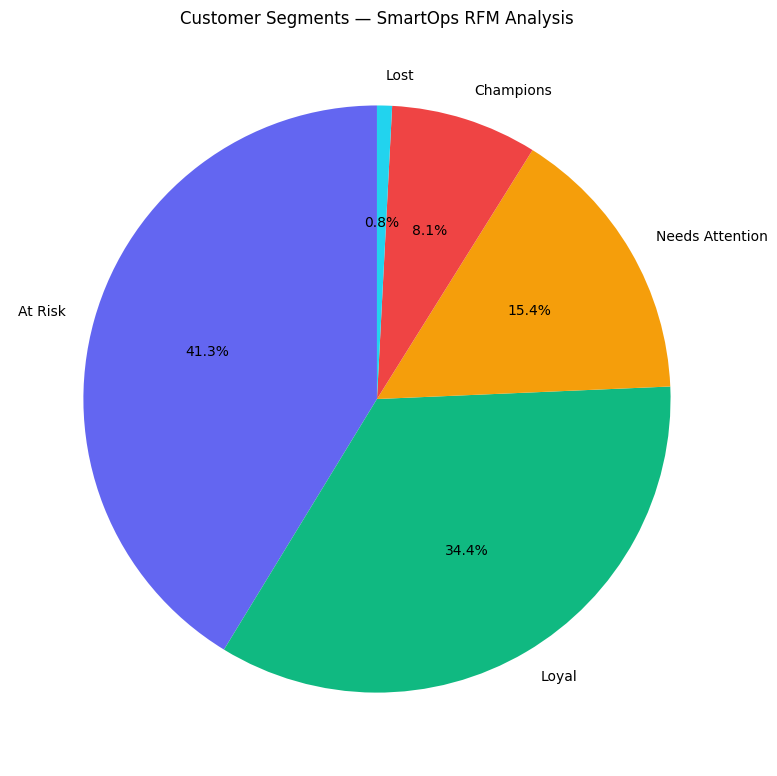

In [4]:
seg_counts = rfm['Segment'].value_counts()

colors = ['#6366F1','#10B981','#F59E0B','#EF4444','#22D3EE']
plt.figure(figsize=(8, 8))
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Customer Segments — SmartOps RFM Analysis')
plt.tight_layout()
plt.savefig('../outputs/customer_segments.png')
plt.show()

In [5]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Label: churned = not ordered in last 180 days
rfm['Churned'] = (rfm['Recency'] > 180).astype(int)

X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model_churn = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_churn.fit(X_train_scaled, y_train)

y_pred = model_churn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print("Module 2 Complete!")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5533
           1       1.00      1.00      1.00     13763

    accuracy                           1.00     19296
   macro avg       1.00      1.00      1.00     19296
weighted avg       1.00      1.00      1.00     19296

Module 2 Complete!


In [6]:
rfm.to_csv('../data/processed/rfm_segments.csv', index=False)
print("RFM segments saved!")
print(f"\nTotal customers analysed: {len(rfm):,}")
print(f"Churned customers: {rfm['Churned'].sum():,}")
print(f"Champions: {(rfm['Segment']=='Champions').sum():,}")
print(f"At Risk: {(rfm['Segment']=='At Risk').sum():,}")

RFM segments saved!

Total customers analysed: 96,478
Churned customers: 68,837
Champions: 7,781
At Risk: 39,822
